# German Sentiment Analysis Demo

This notebook demonstrates a complete end-to-end sentiment analysis system for German text:

- Text preprocessing (German NLP pipeline)
- TF-IDF feature extraction
- Logistic Regression classifier
- Sentiment prediction with probabilities

### Classes:
- Negative
- Neutral
- Positive

### Environment Setup

In [10]:
from pathlib import Path # Path Handling
import pandas as pd # Data Handling

# Project Modules
from utils import load_csv # Data Loading and Preparation
from preprocess_de import preprocess_text # Text Preprocessing Function
from predict_model import predict_sentiment, predict_proba, predict_batch_detailed # Prediction Functions

### Load Model and Vectorizer

In [11]:
BASE_DIR = Path().resolve().parents[0] # Base Directory
DATA_DIR = BASE_DIR / "data" # Data Directory

data_path = DATA_DIR / "train_de.csv"  # Dataset Path

df = load_csv(data_path) # Load Dataset

# Display Dataset Info
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (165, 2)


,text,sentiment
0,"Ich liebe dieses Produkt absolut, es funktioni...",positive
1,"Das ist die schlimmste Erfahrung, die ich je g...",negative
2,Der Film war wirklich unterhaltsam und macht S...,positive
3,Ich bin von der Qualität sehr enttäuscht.,negative
4,"Der Service war okay, nichts Besonderes.",neutral


### Data Overview

In [12]:
# Display Class Distribution
print("Class Distribution:")
print(df["sentiment"].value_counts())

Class Distribution:
sentiment
positive    59
negative    55
neutral     51
Name: count, dtype: int64


### Dataset Visualizations

These plots help inspect label balance before classifier evaluation.

C:\Users\Nikolai\AppData\Local\Temp\ipykernel_14768\3558776122.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


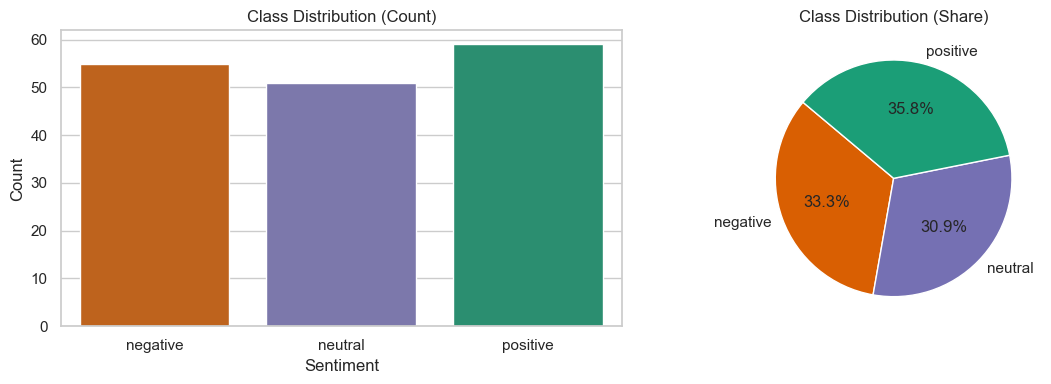

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

label_order = ["negative", "neutral", "positive"]
label_map_numeric = {0: "negative", 1: "neutral", 2: "positive"}

label_series = df["sentiment"].map(label_map_numeric).fillna(df["sentiment"].astype(str).str.lower())
class_counts = label_series.value_counts().reindex(label_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    palette=["#d95f02", "#7570b3", "#1b9e77"],
    ax=axes[0]
    )
axes[0].set_title("Class Distribution (Count)")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")

axes[1].pie(
    class_counts.values,
    labels=class_counts.index,
    autopct="%1.1f%%",
    colors=["#d95f02", "#7570b3", "#1b9e77"],
    startangle=140
    )
axes[1].set_title("Class Distribution (Share)")

plt.tight_layout()
plt.show()

### Preprocessing Demo

In [14]:
sample = "Ich kann nicht glauben, wie gut dieses Produkt ist!!!" # Sample text for preprocessing
processed_text = preprocess_text(sample) # Preprocess sample text

print(f"Original Text: {sample}")
print(f"\nProcessed Text: {processed_text}")


Original Text: Ich kann nicht glauben, wie gut dieses Produkt ist!!!

Processed Text: nicht glauben gut Produkt


### Model Training Explanation

The model was trained using `train_model.py` with:

- TF-IDF vectorization (unigrams + bigrams)
- Logistic Regression classifier
- Calibrated probabilities for better confidence estimates
- Stratified train/test split
- Label mapping:
  - negative → 0
  - neutral → 1
  - positive → 2

The trained model and vectorizer are saved and reused for prediction.

### Single Text Prediction

In [15]:
text = "Dieser Film war fantastisch! Ich habe ihn geliebt." # Sample text for prediction

prediction = predict_sentiment(text) # Predict sentiment
probabilities = predict_proba(text) # Get prediction probabilities

print(f"Text: {text}") 
print(f"Prediction: {prediction}")
print("Probabilites:")
for l, s in probabilities.items():
    print(f"\t{l}: {s:.3f}")

Text: Dieser Film war fantastisch! Ich habe ihn geliebt.
Prediction: positive
Probabilites:
	negative: 0.254
	neutral: 0.148
	positive: 0.599


### Batch Text Prediction

In [16]:
# Sample texts for predictions
examples = [
    "Ich habe diesen Film wirklich genossen!",
    "Das ist das Schlimmste, was ich je erlebt habe.",
    "Es ist okay, nichts Besonderes.",
    "Ich bin sehr glücklich mit diesem Kauf!",
    "Die Qualität ist schlecht und enttäuschend."
]

results = predict_batch_detailed(examples) # Get detailed predictions for batch of texts

for item in results:
    print(f"\nText: {item['text']}")
    print(f"Prediction: {item['prediction']}")
    print("Probabilities:")
    for l, s in item["probabilities"].items():
        print(f"\t{l}: {s:.3f}")


Text: Ich habe diesen Film wirklich genossen!
Prediction: positive
Probabilities:
	negative: 0.161
	neutral: 0.103
	positive: 0.736

Text: Das ist das Schlimmste, was ich je erlebt habe.
Prediction: neutral
Probabilities:
	negative: 0.361
	neutral: 0.248
	positive: 0.391

Text: Es ist okay, nichts Besonderes.
Prediction: neutral
Probabilities:
	negative: 0.091
	neutral: 0.795
	positive: 0.115

Text: Ich bin sehr glücklich mit diesem Kauf!
Prediction: neutral
Probabilities:
	negative: 0.490
	neutral: 0.131
	positive: 0.379

Text: Die Qualität ist schlecht und enttäuschend.
Prediction: negative
Probabilities:
	negative: 0.535
	neutral: 0.124
	positive: 0.341


### Classifier Visual Diagnostics

These charts summarize batch predictions and show confidence behavior.

Note: the confusion matrix uses current notebook data and is for quick diagnostics, not a strict holdout benchmark.

C:\Users\Nikolai\AppData\Local\Temp\ipykernel_14768\1150015042.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


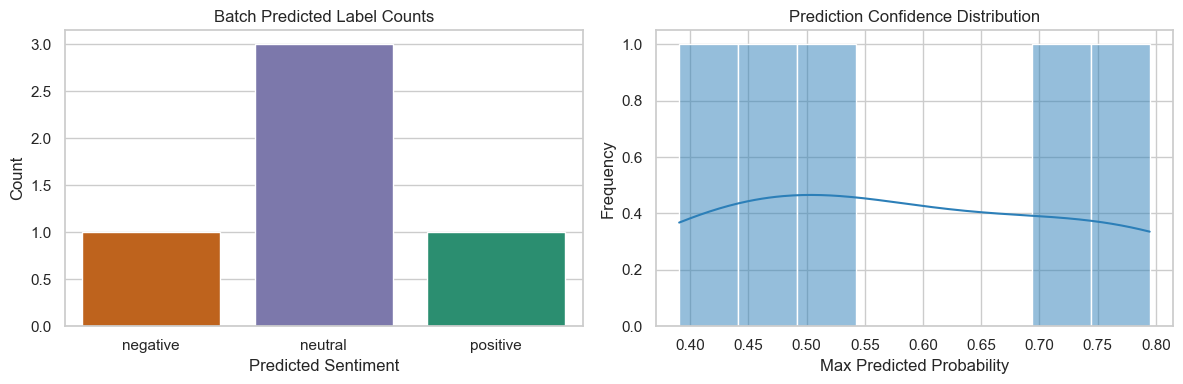

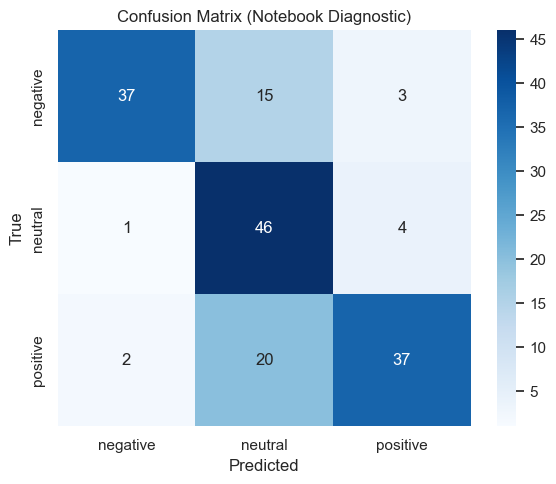

Classification Report (Notebook Diagnostic):
              precision    recall  f1-score   support

    negative       0.93      0.67      0.78        55
     neutral       0.57      0.90      0.70        51
    positive       0.84      0.63      0.72        59

    accuracy                           0.73       165
   macro avg       0.78      0.73      0.73       165
weighted avg       0.78      0.73      0.73       165



In [17]:
from sklearn.metrics import confusion_matrix, classification_report

label_order = ["negative", "neutral", "positive"]

# 1) Batch prediction summary charts
results_df = pd.DataFrame(results)
proba_df = pd.DataFrame(results_df["probabilities"].tolist())

pred_counts = results_df["prediction"].value_counts().reindex(label_order, fill_value=0)
confidence = proba_df.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    x=pred_counts.index,
    y=pred_counts.values,
    palette=["#d95f02", "#7570b3", "#1b9e77"],
    ax=axes[0]
    )
axes[0].set_title("Batch Predicted Label Counts")
axes[0].set_xlabel("Predicted Sentiment")
axes[0].set_ylabel("Count")

sns.histplot(confidence, bins=8, kde=True, color="#2c7fb8", ax=axes[1])
axes[1].set_title("Prediction Confidence Distribution")
axes[1].set_xlabel("Max Predicted Probability")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# 2) Quick confusion matrix on notebook dataset
eval_df = df[["text", "sentiment"]].dropna().copy()
true_labels = eval_df["sentiment"].map({0: "negative", 1: "neutral", 2: "positive"}).fillna(
    eval_df["sentiment"].astype(str).str.lower()
    )
valid_mask = true_labels.isin(label_order)
eval_df = eval_df[valid_mask]
true_labels = true_labels[valid_mask]

pred_labels = eval_df["text"].apply(predict_sentiment)
cm = confusion_matrix(true_labels, pred_labels, labels=label_order)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_order,
    yticklabels=label_order
    )
plt.title("Confusion Matrix (Notebook Diagnostic)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

print("Classification Report (Notebook Diagnostic):")
print(classification_report(true_labels, pred_labels, labels=label_order, zero_division=0))

### Clean Table Output

In [18]:
pd.DataFrame(results)

,text,prediction,probabilities
0,Ich habe diesen Film wirklich genossen!,positive,"{'negative': 0.16130618949119285, 'neutral': 0..."
1,"Das ist das Schlimmste, was ich je erlebt habe.",neutral,"{'negative': 0.3610299808184722, 'neutral': 0...."
2,"Es ist okay, nichts Besonderes.",neutral,"{'negative': 0.09089421243496444, 'neutral': 0..."
3,Ich bin sehr glücklich mit diesem Kauf!,neutral,"{'negative': 0.4904464403603024, 'neutral': 0...."
4,Die Qualität ist schlecht und enttäuschend.,negative,"{'negative': 0.5346135265562068, 'neutral': 0...."


### Interactive Demo

In [19]:
user_input = input("Gib einen Text zur Sentiment-Analyse ein: ") # Get user input
user_prediction = predict_sentiment(user_input) # Predict sentiment for user input
print(f"Predicted Sentiment: {user_prediction}")

Predicted Sentiment: neutral
